In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
def shingles(doc: str, k: int) -> set:
  return set(doc[i : i + k] for i in range(len(doc) - k + 1))

def jaccard(set_a: set, set_b: set) -> float:
  interseccion = set_a & set_b
  union    = set_a | set_b
  return len(interseccion) / len(union) if union else 0.0

def jaccard_minhash(firma1, firma2):
    coincidencias = sum(1 for i, j in zip(firma1, firma2) if i == j)
    return np.round(coincidencias / 100,2)

def make_hash_family(t:int, p:int, seed = 1):
  np.random.seed(seed)
  a = np.random.randint(1, p, size=t, dtype=np.int64)
  b = np.random.randint(0, p, size=t, dtype=np.int64)
  return a,b # en formato array

def hash_shingle(shingle, p):
  return hash(shingle) % p

def minhash_signature(shingle_set, a, b, p):
  t = len(a)
  signature = np.full(t, np.inf)
  for shingle in shingle_set:
    x = hash_shingle(shingle, p)
    # Calcular todos los hash de la familia para el shingle x
    hash_vals = (a * x + b) % p
    signature = np.minimum(signature, hash_vals)
  return signature

def estimated_jaccard(sig_a, sig_b):
  return np.mean(sig_a == sig_b)
def t_(b,r):
    return (1/b)**(1/r)
def limpiar(texto):
    import re
    #Convertir a minúsculas
    texto = texto.lower()

    #Eliminar signos de puntuación usando re.sub
    texto = re.sub(r'[^\w\s]', '', texto)

    #Normalizar espacios: eliminar espacios extra y quitar extremos
    texto = " ".join(texto.split())

    return texto

##**Carga del Dataset**

In [5]:
PATH = "news_es.csv"
df = pd.read_csv(PATH)
df.head()

,url,contenido,categoria
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


##**Actividad 1: Creación y Verificación de k-Shingles**
Preprocesamiento y generación de k-shingles. <br>
Reporte de cómo varía el tamaño promedio del set de shingles por documento según k, usando solo los 20 primeros documentos.


Evaluamos para cada K en { 3, 5, 7}

In [6]:
assert 'df' in globals(), "Se requiere el DataFrame df cargado con la columna 'contenido'"

docs20 = df['contenido'].head(20).fillna("").tolist()
ks = [3, 5, 7]

sizes_by_k = {}
for k_val in ks:
    shingle_sets = [shingles(limpiar(txt), k_val) for txt in docs20]
    sizes = [len(s) for s in shingle_sets]
    sizes_by_k[k_val] = {
        'sizes': sizes,
        'avg': float(np.mean(sizes)),
        'std': float(np.std(sizes, ddof=1)) if len(sizes) > 1 else 0.0
    }
report_rows = []
for k_val in ks:
    report_rows.append({
        'k': k_val,
        'Tam_prom_shingles': sizes_by_k[k_val]['avg'],
        'Desv_estandas': sizes_by_k[k_val]['std']
    })
report_df = pd.DataFrame(report_rows)
print("Resumen de tamaños de sets de shingles (20 documentos):")
report_df



Resumen de tamaños de sets de shingles (20 documentos):


,k,Tam_prom_shingles,Desv_estandas
0,3,833.3,275.398678
1,5,1725.9,828.995835
2,7,2120.4,1125.814157


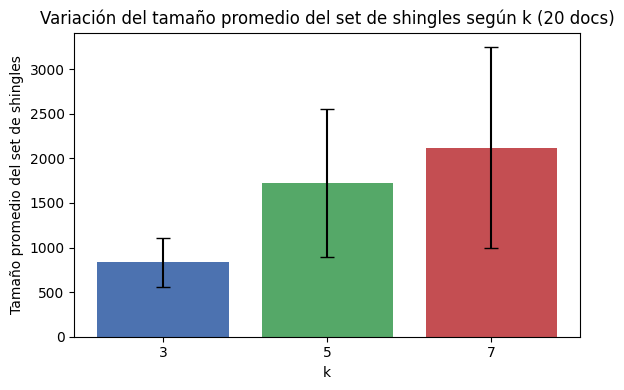

In [7]:

fig, ax = plt.subplots(figsize=(6,4))
means = [sizes_by_k[k]['avg'] for k in ks]
errors = [sizes_by_k[k]['std'] for k in ks]
ax.bar([str(k) for k in ks], means, yerr=errors, capsize=5, color=['#4c72b0','#55a868','#c44e52'])
ax.set_xlabel('k')
ax.set_ylabel('Tamaño promedio del set de shingles')
ax.set_title('Variación del tamaño promedio del set de shingles según k (20 docs)')
plt.tight_layout()
plt.show()


Cuando k = 3 el tamaño del shingle es menor en promedio porque al ser pequeño el token es más probable que colisione con otros tokens y al ser un set la duplicidad se elimina\.  

###**K=7 discrimina mejor**

Es por ello que concluimos que que el k=7 es el k más discriminativo, ya los shingles tienen menos probabilidad de concluir a menos que en efecto los documnetos sean de temas similares y coincidad por naturalidad.\.

##**Actividad 2: Jaccard Exacto sobre Sets de Shingles (Ground Truth)**
Jaccard exacto, ground truth


Definimos parámetros

In [4]:
n = 100
k = 7

# Para seguridad redefinimos p a un primo grande cercano > max_k5
p = 15485863  # primo grande

In [8]:
df.shape

(1217, 3)

In [28]:
# definiendo un universo de aproximadamente 30% para reducir calculo computacional
univ30 = pd.DataFrame(df["contenido"][:405])
#dependiendo del valor de k
shingle_final7 = [shingles(limpiar(i), k) for i in univ30["contenido"]]

In [29]:
jac7 = [(i, j, jaccard(shingle_i, shingle_j))
        for i, shingle_i in enumerate(shingle_final7)
        for j, shingle_j in enumerate(shingle_final7)
        if i < j]

jac7.sort(key=lambda x: x[2], reverse=True)


In [30]:
jac7[:20]

[(11, 236, 1.0),
 (22, 392, 1.0),
 (57, 351, 1.0),
 (95, 142, 1.0),
 (102, 164, 1.0),
 (146, 193, 1.0),
 (176, 340, 1.0),
 (282, 384, 1.0),
 (276, 330, 0.41909814323607425),
 (39, 53, 0.32092198581560283),
 (28, 159, 0.2921686746987952),
 (53, 228, 0.29048295454545453),
 (185, 337, 0.2879581151832461),
 (248, 291, 0.2813983599482089),
 (33, 194, 0.25910476496069307),
 (39, 228, 0.24821002386634844),
 (143, 361, 0.2388543636854904),
 (33, 235, 0.23239323126510877),
 (62, 394, 0.23236651285431772),
 (194, 235, 0.23027295285359803)]

In [31]:
df.iloc[22]['contenido']

'BBVA invertirá un total de 15 millones de euros en Leadwind, un fondo de capital riesgo gestionado por K Fund. En esta primera fase, el fondo acumula 140 millones de euros con los que apoyará a empresas tecnológicas en España, Portugal y Latinoamérica.\r\nLeadwind ha logrado compromisos de capital de inversores corporativos como Telefónica, BBVA, Global Omnium a través de GoHub, y SATEC, entre otras, así como inversores institucionales como AXIS-ICO a través de la iniciativa Fond-ICO Next Tech y distintos ‘family offices’.\r\nLa intención de K Fund es llegar a reunir hasta 250 millones de euros, por lo que sigue abierto a nuevos inversores. BBVA y el resto de socios no solo contribuirán con capital, sino que aportarán a las empresas de la cartera del fondo el conocimiento de sus respectivos negocios y mercados. Leadwind representa la mayor captación realizada por una gestora independiente en España y una oportunidad para promover una nueva ola de emprendimiento y la creación de tecnol

In [32]:
df.iloc[392]['contenido']

'BBVA invertirá un total de 15 millones de euros en Leadwind, un fondo de capital riesgo gestionado por K Fund. En esta primera fase, el fondo acumula 140 millones de euros con los que apoyará a empresas tecnológicas en España, Portugal y Latinoamérica.\r\nLeadwind ha logrado compromisos de capital de inversores corporativos como Telefónica, BBVA, Global Omnium a través de GoHub, y SATEC, entre otras, así como inversores institucionales como AXIS-ICO a través de la iniciativa Fond-ICO Next Tech y distintos ‘family offices’.\r\nLa intención de K Fund es llegar a reunir hasta 250 millones de euros, por lo que sigue abierto a nuevos inversores. BBVA y el resto de socios no solo contribuirán con capital, sino que aportarán a las empresas de la cartera del fondo el conocimiento de sus respectivos negocios y mercados. Leadwind representa la mayor captación realizada por una gestora independiente en España y una oportunidad para promover una nueva ola de emprendimiento y la creación de tecnol

In [33]:
df.iloc[276]['contenido']

"La falta de percepción de riesgo y la escasa implementación de medidas de prevención efectivas, así como contar con equipos obsoletos, son algunas de las causas por las que casi la mitad de pymes  españolas sufrieron un ciberataque el año pasado. Tanto para prevenir, como para combatir y minimizar riesgos tras sufrir un ciberataque es primordial que nuestras empresas cuenten con un plan de ciberseguridad, también en el caso de las pymes, convertidas en uno de los principales objetivos de este tipo de delitos. En este 'podcast' de 'Compartiendo conocimiento' contamos el caso de Palibex, una de las pymes nacionales que lleva años apostando por la ciberseguridad.\r\nBases de datos de clientes, facturas, informes... son muchos los activos de las empresas que pueden convertirse en objeto de ciberataque. Activos con los que también cuentan las pequeñas y medianas empresas, y los profesionales independientes , a los que se dirige un amplio porcentaje de los ataques online. Sin embargo, según

In [34]:
df.iloc[330]['contenido']

"La falta de percepción de riesgo y la escasa implementación de medidas de prevención efectivas, así como contar con equipos obsoletos, son algunas de las causas por las que casi la mitad de pymes  españolas sufrieron un ciberataque el año pasado. Tanto para prevenir, como para combatir y minimizar riesgos tras sufrir un ciberataque es primordial que nuestras empresas cuenten con un plan de ciberseguridad, también en el caso de las pymes, convertidas en uno de los principales objetivos de este tipo de delitos. En este 'podcast' de 'Compartiendo conocimiento' contamos el caso de Palibex, una de las pymes nacionales que lleva años apostando por la ciberseguridad. Bases de datos de clientes, facturas, informes... son muchos los activos de las empresas que pueden convertirse en objeto de ciberataque. Activos con los que también cuentan las pequeñas y medianas empresas, y los profesionales independientes , a los que se dirige un amplio porcentaje de los ataques online. Sin embargo, según af

### Analizando los resultados del Jaccard Exacto  
Los documentos con el mismo contenido tienen un jaccard exacto de 1, previamente comparamos el contenido de estos primeros lugares en el top20 de Jaccard, de los shingles con k=3.  

 Y los que resultan con jaccard < 1 pero igual en el top20, mantienen una relación de contenido entre palabras y contexto. Por lo que sí es lo que se esperaba en los resultados.


## **Actividad 3: Firma MinHash y Jaccard Aproximado**
Firma MinHash y Jaccard aprox.

In [35]:
t = n
a, b = make_hash_family(t=t, p=p, seed=42)

# Calcular firmas para cada documento
signatures7 = []
for sset in shingle_final7:
    sig = minhash_signature(sset, a, b, p)
    signatures7.append(sig)
signatures7 = np.array(signatures7)


In [36]:

jac_estimado7 = [(i, j, jaccard_minhash(firma_i, firma_j))
        for i, firma_i in enumerate(signatures7)
        for j, firma_j in enumerate(signatures7)
        if i < j]
jac_estimado7.sort(key=lambda x: x[2], reverse=True)


In [37]:
jac_estimado7[:20]

[(11, 236, np.float64(1.0)),
 (22, 392, np.float64(1.0)),
 (57, 351, np.float64(1.0)),
 (95, 142, np.float64(1.0)),
 (102, 164, np.float64(1.0)),
 (144, 241, np.float64(1.0)),
 (144, 388, np.float64(1.0)),
 (146, 193, np.float64(1.0)),
 (176, 340, np.float64(1.0)),
 (241, 388, np.float64(1.0)),
 (282, 384, np.float64(1.0)),
 (185, 337, np.float64(0.38)),
 (28, 159, np.float64(0.33)),
 (53, 228, np.float64(0.33)),
 (194, 235, np.float64(0.33)),
 (276, 330, np.float64(0.31)),
 (33, 200, np.float64(0.29)),
 (238, 286, np.float64(0.29)),
 (39, 53, np.float64(0.27)),
 (194, 200, np.float64(0.26))]

Comparativa con el Jaccard exacto


In [38]:
jac7[:20]

[(11, 236, 1.0),
 (22, 392, 1.0),
 (57, 351, 1.0),
 (95, 142, 1.0),
 (102, 164, 1.0),
 (146, 193, 1.0),
 (176, 340, 1.0),
 (282, 384, 1.0),
 (276, 330, 0.41909814323607425),
 (39, 53, 0.32092198581560283),
 (28, 159, 0.2921686746987952),
 (53, 228, 0.29048295454545453),
 (185, 337, 0.2879581151832461),
 (248, 291, 0.2813983599482089),
 (33, 194, 0.25910476496069307),
 (39, 228, 0.24821002386634844),
 (143, 361, 0.2388543636854904),
 (33, 235, 0.23239323126510877),
 (62, 394, 0.23236651285431772),
 (194, 235, 0.23027295285359803)]

Coinciden en el top 5, así como en otros pares con jaccard exacto =1, Sin embargo en los pares con jaccard < 1, hay un poco de variación, que mostraremos con las siguientes métricas.

In [39]:
mismos_pares = 0
mismos_pares_similitud = 0
error = 0
for ji in jac7[:20]:
  for jj in jac_estimado7[:20]:
    if ji[:1]==jj[:1]:
      mismos_pares += 1
      error += abs(ji[2]-jj[2])
    if ji==jj:
      mismos_pares_similitud +=1


In [40]:
mismos_pares

18

In [41]:
mismos_pares_similitud

8

Notamos que del top 20, trajo los mismos 17 pares tanto el jacccard exacto como el estimado, aunque solo 8 con la similitud exactamente igual. Procederemos a calcular el error promedio absoluto del top20.

In [42]:
print(f"{round(error*100/mismos_pares, 2)} %")

3.16 %


## **Actividad 4: LSH por Bandas y Análisis de Pares Candidatos**
LSH por bandas y análisis de pares candidatos

In [43]:
r1 = 5
b_bands1 = t // r1
if b_bands1 * r1 != t:
    r = 4
    b_bands = t // r

In [44]:
candidates = set()
for band in range(b_bands1):
    buckets = defaultdict(list)
    start = band * r1
    end = start + r1
    for idx, sig in enumerate(signatures7):
        band_key = tuple(sig[start:end])
        buckets[band_key].append(idx)
    # Generar pares dentro de cada bucket
    for docs_in_bucket in buckets.values():
        if len(docs_in_bucket) > 1:
            docs_in_bucket = sorted(docs_in_bucket)
            for i in range(len(docs_in_bucket)):
                for j in range(i+1, len(docs_in_bucket)):
                    candidates.add((docs_in_bucket[i], docs_in_bucket[j]))


In [45]:
len_candidates = len(candidates)

#verificación con jaccard exacto
verified = []
for i, j in candidates:
    jac = jaccard(shingle_final7[i], shingle_final7[j])
    verified.append((i, j, jac))

verified_df = pd.DataFrame(verified, columns=["i", "j", "jaccard"]).sort_values("jaccard", ascending=False)

In [46]:
t1 = t_(b_bands1,r1)
t1

0.5492802716530588

In [47]:
resultados_lsh = []

for idx1, idx2 in candidates:
    set1 = shingle_final7[idx1]
    set2 = shingle_final7[idx2]
    sim = jaccard(set1, set2)
    resultados_lsh.append(((idx1, idx2), sim))

resultados_lsh.sort(key=lambda x: x[1], reverse=True)
top_k_lsh_r1 = resultados_lsh[:20]

In [48]:
top_k_lsh_r1

[((146, 193), 1.0),
 ((95, 142), 1.0),
 ((57, 351), 1.0),
 ((102, 164), 1.0),
 ((176, 340), 1.0),
 ((22, 392), 1.0),
 ((11, 236), 1.0),
 ((282, 384), 1.0),
 ((33, 194), 0.25910476496069307),
 ((33, 200), 0.16825208085612367),
 ((144, 241), 0.0),
 ((241, 388), 0.0),
 ((144, 388), 0.0)]

In [ ]:
jac7

In [51]:
len(jac7)

81810

In [52]:
tp_set = [item for item in jac7 if item[2] > t1 ]

In [53]:
gt_dict = {tuple(sorted((item[0], item[1]))): item[2] for item in jac7}

In [ ]:
gt_dict

In [55]:
r2 = 10
b_bands2 = 100 // r2
if b_bands2 * r2 != 100:
    r2 = 4
    b_bands2 = 100 // 2

In [56]:
candidates2 = set()
for band in range(b_bands2):
    buckets = defaultdict(list)
    start = band * r2
    end = start + r2
    for idx, sig in enumerate(signatures7):
        band_key = tuple(sig[start:end])
        buckets[band_key].append(idx)
    # Generar pares dentro de cada bucket
    for docs_in_bucket in buckets.values():
        if len(docs_in_bucket) > 1:
            docs_in_bucket = sorted(docs_in_bucket)
            for i in range(len(docs_in_bucket)):
                for j in range(i+1, len(docs_in_bucket)):
                    candidates2.add((docs_in_bucket[i], docs_in_bucket[j]))

In [57]:
r3 = 4
b_bands3 = 25

In [58]:
candidates3 = set()
for band in range(b_bands3):
    buckets = defaultdict(list)
    start = band * r3
    end = start + r3
    for idx, sig in enumerate(signatures7):
        band_key = tuple(sig[start:end])
        buckets[band_key].append(idx)
    # Generar pares dentro de cada bucket
    for docs_in_bucket in buckets.values():
        if len(docs_in_bucket) > 1:
            docs_in_bucket = sorted(docs_in_bucket)
            for i in range(len(docs_in_bucket)):
                for j in range(i+1, len(docs_in_bucket)):
                    candidates3.add((docs_in_bucket[i], docs_in_bucket[j]))

In [59]:
def generar_fila_tabla(b, r, candidates, gt_dict, t):

    reales_positivos = {par for par, sim in gt_dict.items() if sim >= t}

    tp_set = {par for par in candidates if gt_dict.get(par, 0) >= t}

    tp = len(tp_set)
    fp = len(candidates) - tp
    fn = len(reales_positivos - candidates)

    # 4. Métricas
    precision = tp / len(candidates) if len(candidates) > 0 else 0
    recall = tp / len(reales_positivos) if len(reales_positivos) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "Propuesta": f"{b}, {r}",
        "Umbral t": round(t, 3),
        "# Candidatos": len(candidates),
        "Precisión": round(precision, 3),
        "Recall": round(recall, 3),
        "F1": round(f1, 3),
        "FP/FN": f"{fp} / {fn}"
    }

In [60]:
exp1 =generar_fila_tabla(b_bands1, r1, candidates, gt_dict, t_(b_bands1, r1))
exp2 =generar_fila_tabla(b_bands2, r2, candidates2, gt_dict,  t_(b_bands2, r2))
exp3 =generar_fila_tabla(b_bands3, r3, candidates3, gt_dict,  t_(b_bands3, r3))


In [61]:
data = [exp1, exp2, exp3]
dfF = pd.DataFrame(data)
dfF

,Propuesta,Umbral t,# Candidatos,Precisión,Recall,F1,FP/FN
0,"20, 5",0.549,13,0.615,1.0,0.762,5 / 0
1,"10, 10",0.794,11,0.727,1.0,0.842,3 / 0
2,"25, 4",0.447,19,0.421,1.0,0.593,11 / 0


La propuesta de b,r con mejor F1 Scores es la de 10, 10. Aunque todas obtienen un recall =1, captan las similitudes importantes. Como esta opción formula un umbral t más alto, reducimos la recolección de falsos positivos y por eso es más preciso.  

Y por eso sería la opción que escogeriamos si el costo de revisar un falso positivo fuera alto.

## **Actividad 5: Visualización y Análisis de Calidad del Pipeline**
Visualización


In [62]:
jac7_vis = [(jaccard(shingle_i, shingle_j))
        for i, shingle_i in enumerate(shingle_final7)
        for j, shingle_j in enumerate(shingle_final7)
        if i < j]

jac_estimado7_vis= [( jaccard_minhash(firma_i, firma_j))
        for i, firma_i in enumerate(signatures7)
        for j, firma_j in enumerate(signatures7)
        if i < j]

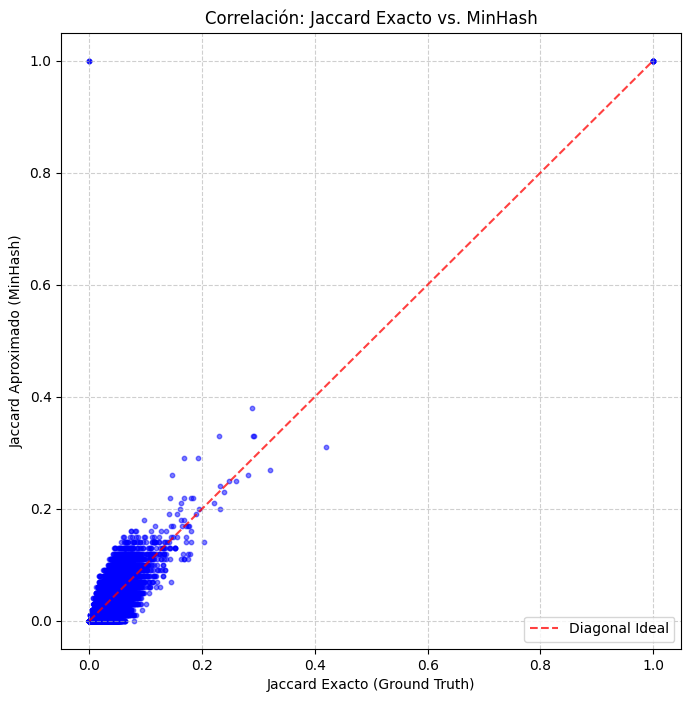

In [63]:
plt.figure(figsize=(8, 8))
plt.scatter(jac7_vis, jac_estimado7_vis, alpha=0.5, color='blue', s=10)

# Diagonal ideal (x = y)
lims = [0, 1]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label="Diagonal Ideal")

plt.title('Correlación: Jaccard Exacto vs. MinHash')
plt.xlabel('Jaccard Exacto (Ground Truth)')
plt.ylabel('Jaccard Aproximado (MinHash)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Si nos centramos más en la comparación de similitudes que no llegan a ser 1. Pordemos observar que la mayoria de puntos se concentran cerca de la línea ideal, pero no lo suficiente. Esto se podría mejorar con la #de hashes, si la aumentamos podríamos converger más al valor real.

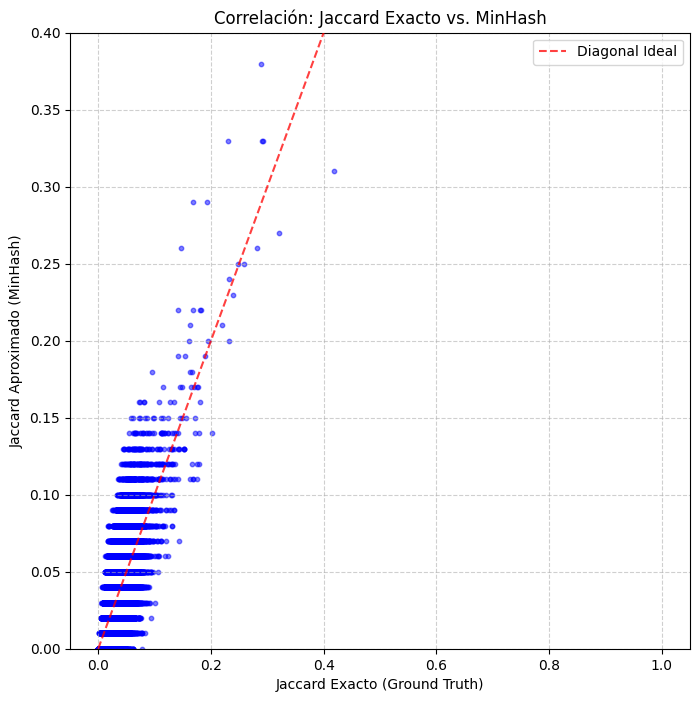

In [64]:
plt.figure(figsize=(8, 8))
plt.scatter(jac7_vis, jac_estimado7_vis, alpha=0.5, color='blue', s=10)

# Diagonal ideal (x = y)
lims = [0, 1]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label="Diagonal Ideal")

plt.title('Correlación: Jaccard Exacto vs. MinHash')
plt.xlabel('Jaccard Exacto (Ground Truth)')
plt.ylabel('Jaccard Aproximado (MinHash)')
plt.ylim(0,0.4)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [65]:
def plot_lsh_histogram(candidates_jaccard, t, config_name):

    vps = [sim for sim in candidates_jaccard if sim >= t]
    fps = [sim for sim in candidates_jaccard if sim < t]

    plt.figure(figsize=(10, 6))

    plt.hist([vps, fps], bins=15, stacked=True, color=['green', 'red'],
             label=['Verdaderos Positivos (VP)', 'Falsos Positivos (FP)'], edgecolor='black')

    plt.axvline(t, color='blue', linestyle='dashed', linewidth=2, label=f'Umbral t ({t:.2f})')

    plt.title(f'Distribución de Similitud en Candidatos - {config_name}')
    plt.xlabel('Jaccard Exacto')
    plt.ylabel('Frecuencia (Pares)')
    plt.legend()
    plt.show()


In [71]:
# sim1= [sim for par, sim in gt_dict.items() if sim >= t_(b_bands1,r1)]
# sim2= [sim for par, sim in gt_dict.items() if sim >= t_(b_bands2,r2)]
# sim3= [sim for par, sim in gt_dict.items() if sim >= t_(b_bands3,r3)]
# Obtenemos el Jaccard exacto solo para los candidatos generados por cada configuración LSH
sim1 = [gt_dict.get(tuple(sorted(par)), 0) for par in candidates]
sim2 = [gt_dict.get(tuple(sorted(par)), 0) for par in candidates2]
sim3 = [gt_dict.get(tuple(sorted(par)), 0) for par in candidates3]

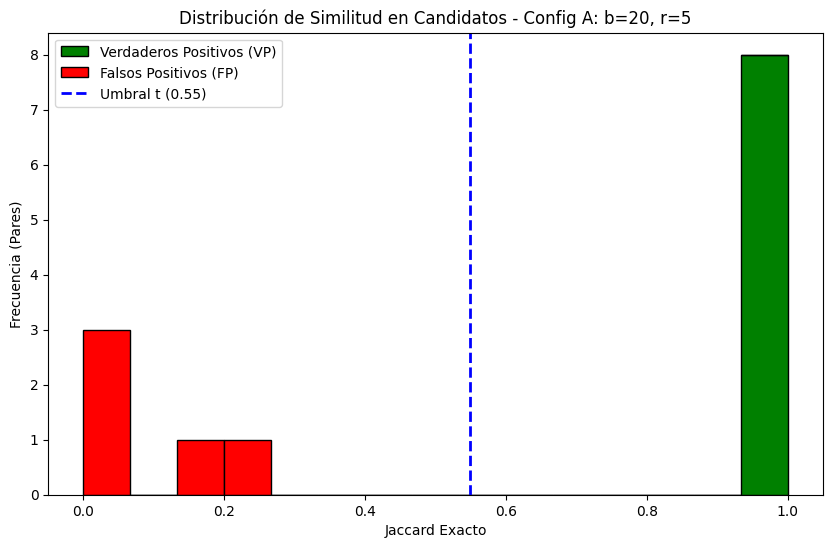

In [76]:
#plot_lsh_histogram(sim1, 0.54, "Config A: b=20, r=5")
t1 = t_(b_bands1, r1)
plot_lsh_histogram(sim1, t1, f"Config A: b={b_bands1}, r={r1}")

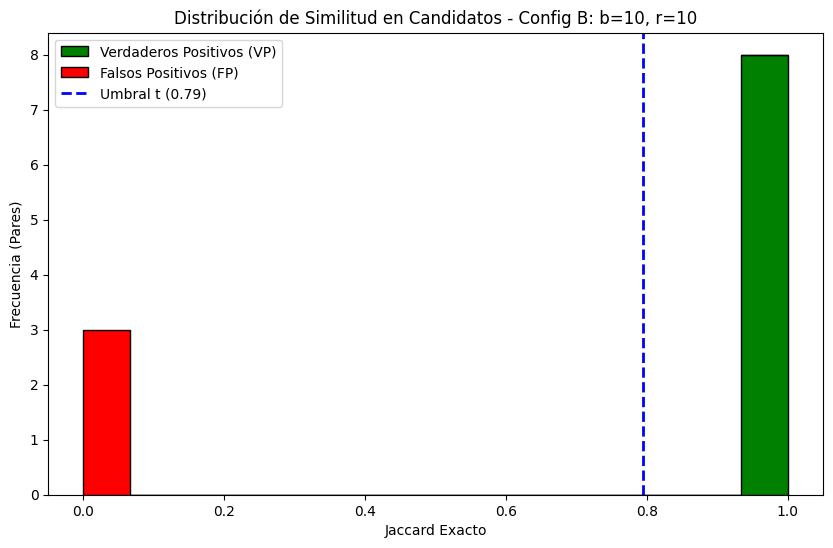

In [75]:
#plot_lsh_histogram(sim2, 0.79, "Config A: b=10, r=10")
t2 = t_(b_bands2, r2)
plot_lsh_histogram(sim2, t2, f"Config B: b={b_bands2}, r={r2}")

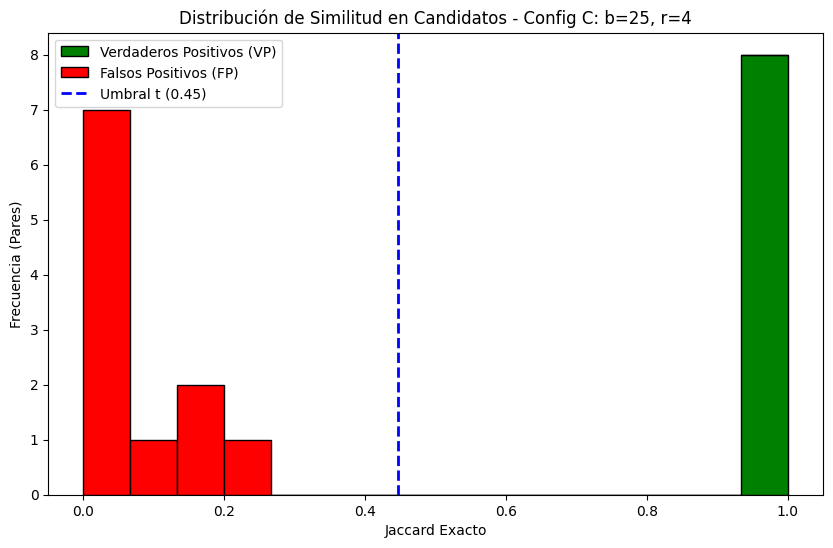

In [77]:
# plot_lsh_histogram(sim3, 0.44, "Config A: b=25, r=4")
t3 = t_(b_bands3, r3)
plot_lsh_histogram(sim3, t3, f"Config C: b={b_bands3}, r={r3}")

##**Resumen de aprendizaje**

El pipeline de detección de similitud comienza con el **Jaccard Exacto**, que actúa como nuestro ground truth al medir la intersección real entre shingles, este caso k=7 por ser el más discriminativo. Al avanzar hacia el **Jaccard aproximado por MinHash**, el perdemos precisión por eficiencia, comprimiendo documentos pesados en firmas numéricas. Con $n=100$ funciones hash, ganamos la capacidad de procesar miles de archivos, data masiva. En esta etapa la dispersión es visible en el *scatter plot*, donde los puntos se alejan levemente de la diagonal ideal, mostrandonos que solo es un aproximado al jaccard exacto.

La mayor pérdida de información que detectamos ocurre en la etapa de **Candidatos LSH**, donde el umbral $t$ actúa como un filtro. En nuestro experimento **Propuesta 2 ($b=10, r=10$, $t=0.79$)**, el filtro es tan estricto que reduce el ruido a solo **3 Falsos Positivos**, pero corre el riesgo de descartar pares con similitud moderada. En cambio, la **Propuesta 3 ($t=0.44$)** eleva los candidatos a 17, disparando los **Falsos Positivos a 9**. Esta etapa es donde se "pierden" documentos (Falsos Negativos) si el umbral es demasiado alto, o se "gana" trabajo innecesario si es demasiado bajo, Es por eso que la elección de $b$ y $r$ juega un rol importante.

Este pipeline es esencial para **datos masivos** porque ataca la completjidad cuadrática ($O(N^2)$). Por ejemplo, sin LSH, comparar 10,000 documentos requeriría 50 millones de comparaciones exactas; con LSH, solo analizamos una fracción de pares candidatos que colisionan en los buckets. La combinación de MinHash, que reduce el tamaño de los datos, y LSH, que reduce el número de comparaciones, permite que el sistema escale de forma lineal, haciendo factibel y fácilmente computable el análisis de similitud que se requiera.